<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment/blob/main/ESAA_YB_WEEK13_study_0525.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ch7. 3~4 (p.449 ~ 463)

##7.3 평균 이동

###평균 이동(Mean Shift)의 개요
- 평균 이동(Mean Shift)은 데이터가 가장 밀집된 위치를 군집 중심으로 이동시키며 군집화를 수행함.
- 데이터 분포의 확률 밀도 함수(PDF)를 이용해 밀도가 가장 높은 지점(피크)을 군집 중심으로 찾음.
- KDE(Kernel Density Estimation)를 활용하여 중심점을 반복적으로 이동시키면서 최종 군집 중심을 결정함.

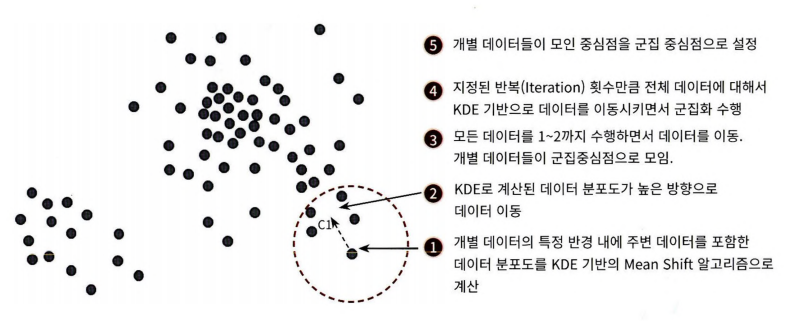

- KDE(Kernel Density Estimation)는 커널 함수를 이용해 데이터의 확률 밀도 함수를 추정하는 방법임.
- 각 관측 데이터에 커널 함수를 적용한 값을 모두 합한 뒤 데이터 수로 나누어 확률 밀도 함수를 계산함.
- 대표적으로 가우시안(정규분포) 커널을 사용하며, 이를 통해 데이터 분포와 밀집 정도를 파악할 수 있음.
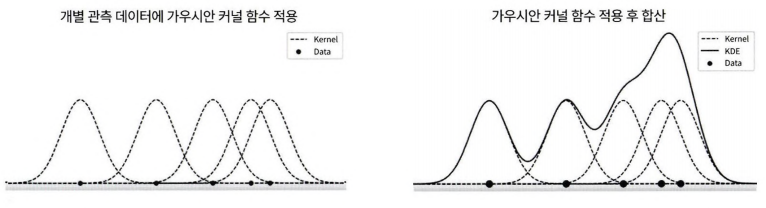

- 커널 함수식
  - K: 커널 함수
  - x: 확률 변숫값
  - xi: 관측값
  - h: 대역폭(bandwidth)

$$
\mathrm{KDE}
=
\frac{1}{n}\sum_{i=1}^{n} K_h(x-x_i)
=
\frac{1}{nh}\sum_{i=1}^{n}
K\!\left(\frac{x-x_i}{h}\right)
$$
___
- 대역폭(bandwidth, h)은 KDE의 곡선을 얼마나 부드럽게 만들지 결정하는 중요한 파라미터임.
- h가 너무 작으면 분포가 지나치게 뾰족해져 과적합되기 쉽고 h가 너무 크면 과도하게 평활화되어 과소적합되기 쉬움.
- 따라서 적절한 대역폭 선택은 KDE의 성능뿐만 아니라 Mean Shift 군집화의 성능에도 매우 중요함.
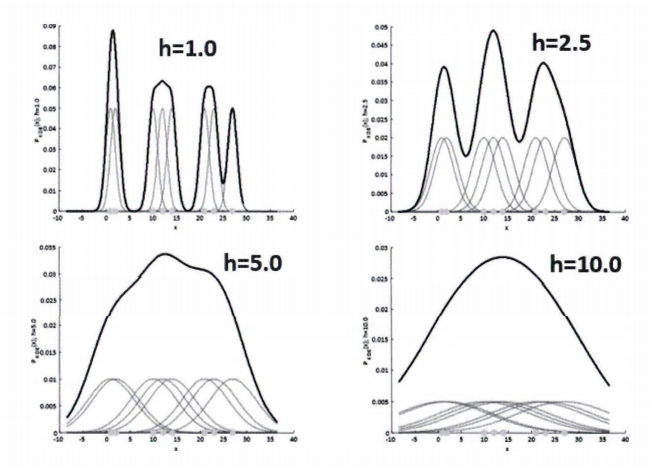

- Mean Shift는 대역폭(bandwidth)에 따라 군집 수가 결정되며, 대역폭이 클수록 군집 수는 줄고 작을수록 군집 수는 늘어남.
- bandwidth 값에 따라 군집 개수가 크게 달라질 수 있으므로 최적의 값을 선택하는 것이 중요함.
- K-평균과 달리 군집 개수를 직접 지정하지 않고 대역폭을 기준으로 군집화를 수행함.
- 사이킷런의 MeanShift 클래스는 bandwidth를 주요 파라미터로 사용하며, estimate_bandwidth()로 적절한 값을 추정할 수 있음.

In [2]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift

X, y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.7, random_state=0)

meanshift=MeanShift(bandwidth=0.8)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2 3 4 5]


- bandwidth 값을 작게 할수록 군집 개수가 많아짐.

In [3]:
meanshift = MeanShift(bandwidth=1)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]


In [4]:
from sklearn.cluster import estimate_bandwidth

bandwidth = estimate_bandwidth(X)
print('bandwidth 값:', round(bandwidth, 3))

bandwidth 값: 1.816


In [5]:
import pandas as pd

clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y

# estimate_bandwidth()로 최적의 bandwidth 계산
best_bandwidth = estimate_bandwidth(X)

meanshift = MeanShift(bandwidth=best_bandwidth)
cluster_labels = meanshift.fit_predict(X)
print('cluster labels 유형:', np.unique(cluster_labels))

cluster labels 유형: [0 1 2]


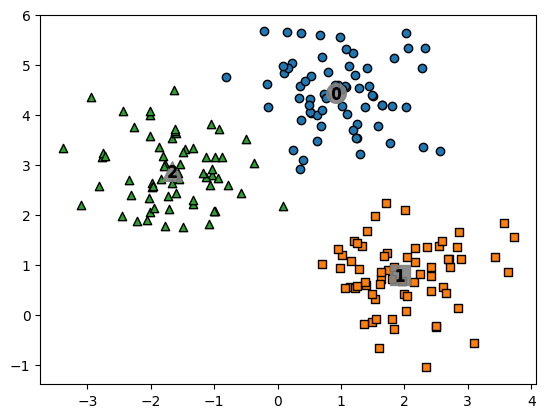

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

clusterDF['meanshift_label'] = cluster_labels
centers = meanshift.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o', 's', '^', 'x', '*']

for label in unique_labels:
  label_cluster = clusterDF[clusterDF['meanshift_label']==label]
  center_x_y = centers[label]
  # 군집별로 다른 마커로 산점도 적용
  plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k', marker=markers[label])

  # 군집별로 중심 표현
  plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='gray', alpha=0.9, marker=markers[label])
  plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k', marker='$%d$' % label)

plt.show()

In [8]:
print(clusterDF.groupby('target')['meanshift_label'].value_counts())

target  meanshift_label
0       0                  67
1       1                  67
2       2                  66
Name: count, dtype: int64


- 평균 이동은 데이터 분포를 특정 형태로 가정하지 않아 유연한 군집화가 가능하며, 이상치의 영향도 비교적 적고 군집 개수를 미리 정할 필요가 없음.
- 반면 계산량이 많아 수행 시간이 오래 걸리고, bandwidth 값에 따라 군집화 결과가 크게 달라짐.
- 이러한 특성 때문에 일반 데이터 분석보다는 컴퓨터 비전 분야에서 객체 인식이나 움직임 추적에 주로 활용됨.

##7.4 GMM(Gaussian Mixture Model)

###GMM(Gaussian Mixture Model) 소개
- GMM(Gaussian Mixture Model)은 데이터가 여러 개의 가우시안(정규) 분포가 섞여 생성되었다고 가정하고 군집화를 수행함.
- 가우시안 분포는 평균을 중심으로 종(bell) 모양의 대칭적인 확률 분포를 가지며, 평균과 표준편차로 특성이 결정됨.
- GMM은 혼합된 데이터에서 각 가우시안 분포를 추정하여 데이터가 속할 가능성이 높은 군집을 찾음.
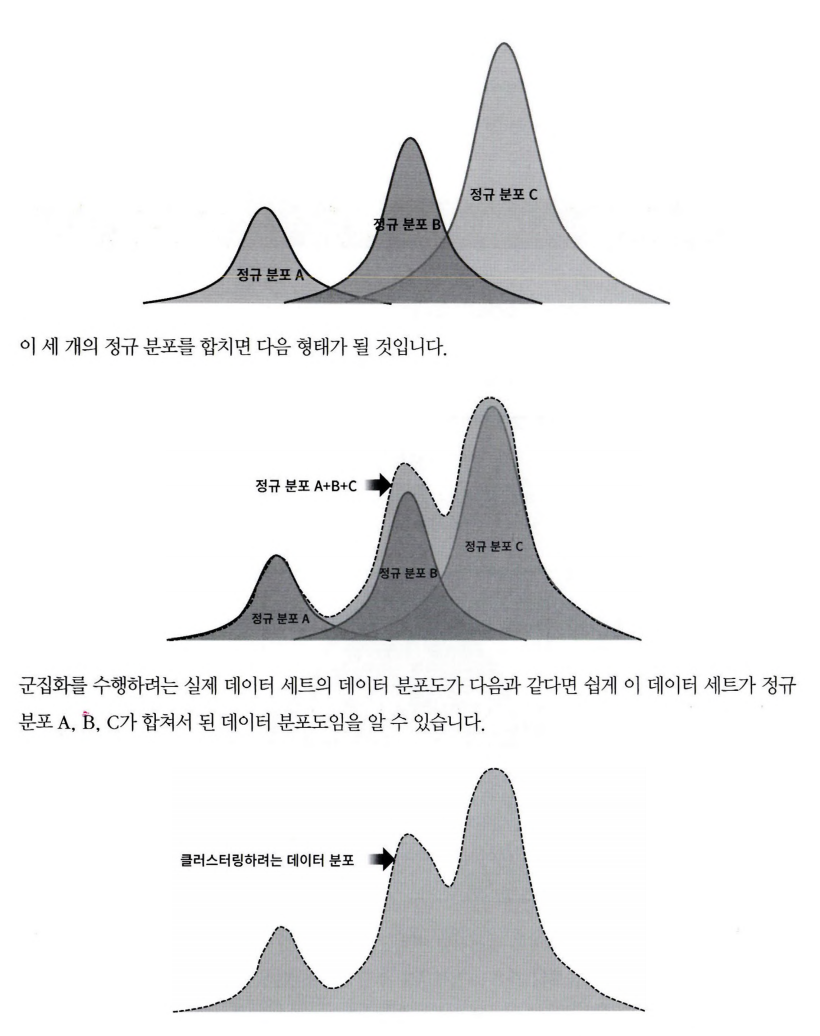

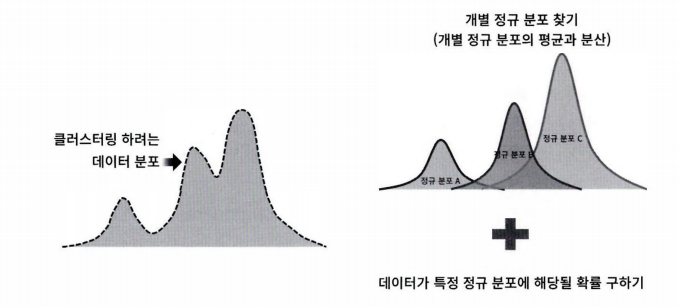


- GMM은 데이터가 여러 개의 서로 다른 정규분포로 구성되어 있다고 가정하고 군집화를 수행함.
- 군집화를 위해 각 정규분포의 평균과 분산, 그리고 각 데이터가 특정 정규분포에 속할 확률을 추정함.
- 이러한 모수 추정을 위해 EM(Expectation-Maximization) 알고리즘을 사용하며, 사이킷런에서는 GaussianMixture 클래스로 지원함.

###GMM을 이용한 붓꽃 데이터 세트 군집화
- GMM은 확률 기반 군집화이고 K-평균은 거리 기반 군집화
- 붓꽃 데이터 세트로 이 두 가지 방식을 이용해 군집화를 수행한 뒤 양쪽 방식을 비교

In [9]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# 좀 더 편리한 데이터 Handling을 위해 DataFrame으로 변환
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)
irisDF['target'] = iris.target

- GaussianMixture의 핵심 파라미터인 n_components는 가우시안 분포(군집)의 개수를 지정함.
- 이는 K-평균의 n_clusters와 유사하게 군집화 결과를 결정하는 중요한 역할을 함.
- fit()으로 모델을 학습하고 predict()로 군집을 예측한 뒤, 결과를 데이터에 저장하여 실제 타깃과의 매핑을 확인할 수 있음.

In [11]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=0).fit(iris.data)
gmm_cluster_labels = gmm.predict(iris.data)

# 군집화 결과를 irisDF의 'gmm_cluster' 칼럼명으로 저장
irisDF['gmm_cluster'] = gmm_cluster_labels
irisDF['target'] = iris.target

# target 값에 따라 gmm_cluster 값이 어떻게 매핑됐는지 확인.
iris_result = irisDF.groupby(['target'])['gmm_cluster'].value_counts()
print(iris_result)

target  gmm_cluster
0       1              50
1       0              45
        2               5
2       2              50
Name: count, dtype: int64


In [16]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0).fit(iris.data)
kmeans_cluster_labels = kmeans.predict(iris.data)
irisDF['kmeans_cluster'] = kmeans_cluster_labels
iris_result = irisDF.groupby(['target'])['kmeans_cluster'].value_counts()
print(iris_result)

target  kmeans_cluster
0       1                 50
1       0                 47
        2                  3
2       2                 36
        0                 14
Name: count, dtype: int64


###GMM과 K-평균의 비교
- K-Means는 원형(구형)에 가까운 형태의 데이터에서 군집화 성능이 가장 우수함.
- cluster_std 값을 작게 설정하면 데이터가 중심 주변에 밀집되어 원형 형태의 군집이 형성됨.
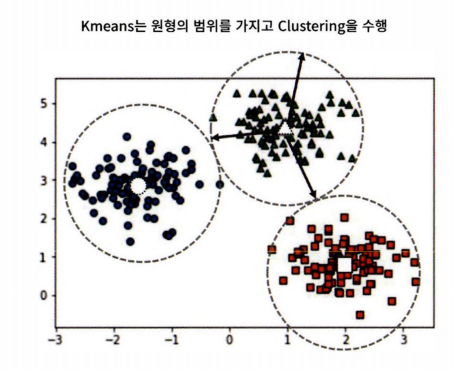

####데이터가 원형의 범위로 퍼져 있지 않는 경우
```{b}
함수명: visualize_cluster_plot(clusterobj, dataframe, label_name, iscluster=True)
```
- clusterobj
  - 사이킷런의 군집 수행 객체
  - KMeans나 GaussianMixture의 fit()와 predict()로 군집화를 완료한 객체
  - 만약 군집화 결과가 아니고 make_blobs()로 생성한 데이터의 시각화일 경우 None 입력
- dataframe
  - 피처 데이터 세트와 label 값을 가진 DataFrame
- label_name
  - 군집화 결과 시각화일 경우 dataframe 내의 군집화 label 칼럼명
  - make_blobs() 결과 시각화일 경우는 dataframe 내의 target 칼럼명
- iscenter
  - 사이킷런 Cluster 객체가 군집 중심 좌표를 제공하면 True, 그렇지 않으면 False

In [19]:
# GMM에서 사용한 시각화 함수
def visualize_cluster_plot(clusterobj, dataframe, label_name, iscenter=True):

    # 군집별 중심 위치: K-Means, Mean Shift 등
    if iscenter:
        centers = clusterobj.cluster_centers_

    # Cluster 값 종류
    unique_labels = np.unique(dataframe[label_name].values)

    markers=['o', 's', '^', 'x', '*']
    isNoise=False

    for label in unique_labels:
        # 군집별 데이터 프레임
        label_cluster = dataframe[dataframe[label_name]==label]

        if label == -1:
            cluster_legend = 'Noise'
            isNoise=True
        else:
            cluster_legend = 'Cluster '+str(label)

        # 각 군집 시각화
        plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], s=70,
                    edgecolor='k', marker=markers[label], label=cluster_legend)

        # 군집별 중심 위치 시각화
        if iscenter:
            center_x_y = centers[label]
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=250, color='white',
                        alpha=0.9, edgecolor='k', marker=markers[label])
            plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k',\
                        edgecolor='k', marker='$%d$' % label)

    if isNoise:
        legend_loc='upper center'
    else:
        legend_loc='upper right'

    plt.legend(loc=legend_loc)
    plt.show()

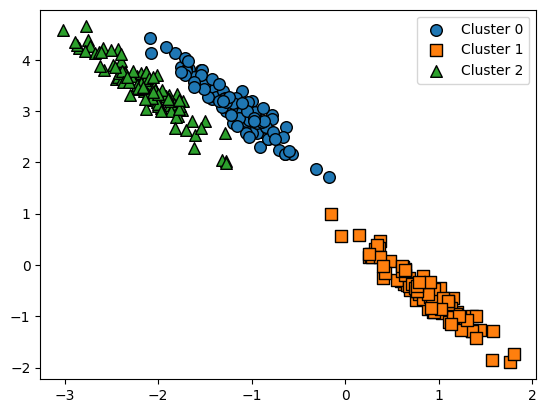

In [20]:
from sklearn.datasets import make_blobs

# make_blobs()로 300개의 데이터 세트, 3개의 군집 세트, cluster_std=0.5를 만듦.
X, y = make_blobs(n_samples=300, n_features=2, centers=3, cluster_std=0.5, random_state=0)

# 길게 늘어난 타원형의 데이터 세트를 생성하기 위해 변환함.
transformation = [[0.60834549, -0.63667341], [-0.40887717, 0.85253229]]
X_aniso = np.dot(X, transformation)
# feature 데이터 세트와 make_blobs()의 y결괏값을 DataFrame으로 저장
clusterDF = pd.DataFrame(data=X_aniso, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y
# 생성된 데이터 세트를 target별로 다른 마커로 표시해 시각화함
visualize_cluster_plot(None, clusterDF, 'target', iscenter=False)

####KMeans가 데이터 세트를 군집화 과정

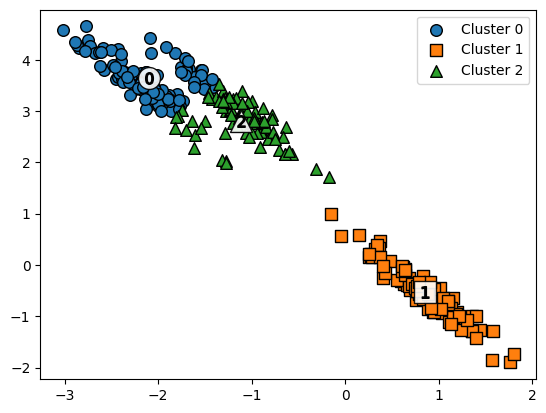

In [22]:
# 3개의 군집 기반 KMeans를 X_aniso 데이터 세트에 적용
kmeans = KMeans(3, random_state=0)
kmeans_label = kmeans.fit_predict(X_aniso)
clusterDF['kmeans_label'] = kmeans_label

visualize_cluster_plot(kmeans, clusterDF, 'kmeans_label', iscenter=True)

- K-Means는 평균 거리 기반으로 군집을 형성하므로 주로 원형 형태로 군집화가 이루어짐.
- 데이터가 길쭉하거나 비선형적인 형태로 분포된 경우에는 최적의 군집을 찾기 어려움.
- 이러한 경우에는 데이터 분포 형태를 고려하는 GMM이 K-Means보다 더 적절한 군집화를 수행할 수 있음.

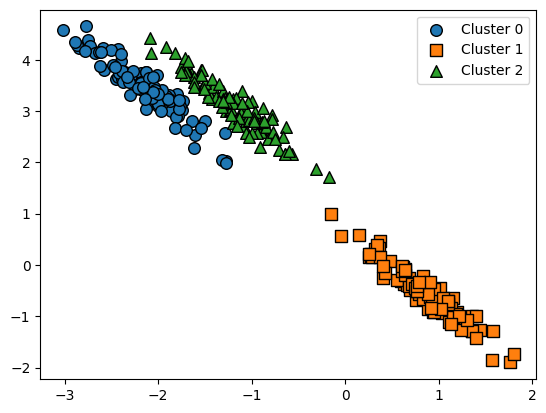

In [24]:
# 3개의 n_components 기반 GMM을 X_aniso 데이터 세트에 적용
gmm = GaussianMixture(n_components=3, random_state=0)
gmm_label = gmm.fit(X_aniso).predict(X_aniso)
clusterDF['gmm_label'] = gmm_label

# GaussianMixture는 cluster_centers_ 속성이 없으므로 iscenter를 False로 설정.
visualize_cluster_plot(gmm, clusterDF, 'gmm_label', iscenter=False)

- GMM은 데이터가 분포된 방향과 형태를 고려하므로 길쭉한 형태의 데이터도 정확하게 군집화할 수 있음.
- K-Means와 달리 명확한 군집 중심 좌표를 계산하지 않으므로 군집 중심을 시각화하기 어려움.
- 실제 타깃값과 K-Means·GMM의 군집 레이블을 비교하면 두 알고리즘의 군집화 성능 차이를 확인할 수 있음.

In [26]:
print('### KMeans Clustering ###')
print(clusterDF.groupby('target')['kmeans_label'].value_counts())
print('\n### Gaussian Mixture Clustering ###')
print(clusterDF.groupby('target')['gmm_label'].value_counts())

### KMeans Clustering ###
target  kmeans_label
0       2                73
        0                27
1       1               100
2       0                86
        2                14
Name: count, dtype: int64

### Gaussian Mixture Clustering ###
target  gmm_label
0       2            100
1       1            100
2       0            100
Name: count, dtype: int64


- K-Means는 일부 군집만 정확하게 매핑되고, 다른 군집에서는 실제 타깃값과 차이가 발생함.
- GMM은 군집 레이블이 실제 타깃값과 잘 일치하여 더 정확한 군집화를 수행함.
- GMM은 다양한 데이터 형태에 유연하게 적용할 수 있지만, K-Means보다 연산량이 많아 수행 시간이 오래 걸림.